In [22]:
#run the following in the command line: 
# earthengine authenticate
import ee
import geemap.core as geemap
ee.Initialize(project='leafy-racer-455619-g4')


In [60]:
def mask_s2_clouds(image):
  """Masks clouds in a Sentinel-2 image using the QA band.

  Args:
      image (ee.Image): A Sentinel-2 image.

  Returns:
      ee.Image: A cloud-masked Sentinel-2 image.
  """
  qa = image.select('QA60')

  # Bits 10 and 11 are clouds and cirrus, respectively.
  cloud_bit_mask = 1 << 10
  cirrus_bit_mask = 1 << 11

  # Both flags should be set to zero, indicating clear conditions.
  mask = (
      qa.bitwiseAnd(cloud_bit_mask)
      .eq(0)
      .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
  )

  return image.updateMask(mask).divide(10000)

xmin, ymin, xmax, ymax = 10.4, 53.5, 10.8, 53.7

roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-01-01', '2020-01-30')
    .filterBounds(roi)
    # Pre-filter to get less cloudy granules.
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds)
)

visualization = {
    'min': 0.0,
    'max': 0.3,
    'bands': ['B4', 'B3', 'B2'],
}

m = geemap.Map()
m.set_center(xmin, ymin, 12)
m.add_layer(dataset.mean(), visualization, 'RGB')
m

Map(center=[53.5, 10.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [ ]:
roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])


dataset = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2020-01-01', '2020-02-02')
    .filterBounds(roi)
)

samples = dataset.first().sample(
    region=roi,
    scale=10,
    numPixels=10,
    geometries=True,
    dropNulls=False,
)

bands_df = ee.data.computeFeatures({
    'expression': samples,
    'fileFormat': 'PANDAS_DATAFRAME'
})

bands_df

,geo,AOT,B1,B11,B12,B2,B3,B4,B5,B6,...,MSK_CLDPRB,MSK_SNWPRB,QA10,QA20,QA60,SCL,TCI_B,TCI_G,TCI_R,WVP
0,"{'type': 'Point', 'coordinates': [10.555943141...",156.0,491.0,1390.0,842.0,352.0,431.0,421.0,796.0,1161.0,...,0.0,0.0,None,None,0.0,5.0,36.0,44.0,43.0,711.0
1,"{'type': 'Point', 'coordinates': [10.412404645...",156.0,985.0,276.0,200.0,561.0,448.0,416.0,574.0,806.0,...,0.0,0.0,None,None,0.0,5.0,57.0,46.0,43.0,433.0
2,"{'type': 'Point', 'coordinates': [10.481263135...",156.0,893.0,1193.0,1000.0,902.0,844.0,932.0,1253.0,1565.0,...,0.0,0.0,None,None,0.0,5.0,92.0,86.0,95.0,899.0
3,"{'type': 'Point', 'coordinates': [10.438453137...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,None,None,0.0,NaN,NaN,NaN,NaN,NaN
4,"{'type': 'Point', 'coordinates': [10.766665499...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
5,"{'type': 'Point', 'coordinates': [10.796793053...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
6,"{'type': 'Point', 'coordinates': [10.669060707...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
7,"{'type': 'Point', 'coordinates': [10.754884148...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
8,"{'type': 'Point', 'coordinates': [10.702970762...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,NaN
9,"{'type': 'Point', 'coordinates': [10.654263371...",156.0,575.0,1277.0,773.0,398.0,383.0,356.0,785.0,1172.0,...,0.0,0.0,None,None,0.0,5.0,41.0,39.0,37.0,754.0


In [66]:
m = geemap.Map()
m.set_center(xmin, ymin, 12)
styled = samples.style(
    color='000000FF',
    fillColor='00000000',
    styleProperty='style',
    neighborhood=6,  # increase to correctly draw large points
)
m.add_layer(styled)
m.add_layer(roi, {}, 'ROI')
display(m)

Map(center=[53.5, 10.4], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

In [83]:
dates = {y: (f'20{y}-06-01', f'20{y}-06-30') for y in range(17, 26)}

In [84]:

roi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])
df_dict = {}
points = samples.map(lambda f: f.set("point_id", f.id()))


for (start_of_month, end_of_month) in dates.values():
    print(start_of_month)
    median_for_month: ee.Image = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(start_of_month, end_of_month)
        .filterBounds(roi)
        .map(mask_s2_clouds)
        .select(["B2", "B3", "B4", "B8"])
        .median()
    )
    values_at_points = median_for_month.sampleRegions(
        collection=points,
        properties=["point_id"],
        scale=10,
        geometries=True,
    )

    if (values_at_points.size().getInfo() == 0):
        print(f"No samples for {start_of_month}")
        continue

    bands_df = ee.data.computeFeatures({
        'expression': values_at_points,
        'fileFormat': 'PANDAS_DATAFRAME'
    })
    df_dict[start_of_month] = bands_df
    

2017-06-01
2018-06-01
2019-06-01
2020-06-01
2021-06-01
2022-06-01
2023-06-01
2024-06-01
2025-06-01


In [85]:
df_dict[dates[18][0]]

,geo,B2,B3,B4,B8,point_id
0,"{'type': 'Point', 'coordinates': [10.555968156...",0.02325,0.0322,0.01835,0.4936,0
1,"{'type': 'Point', 'coordinates': [10.412417373...",0.06490,0.1089,0.09920,0.3500,1
2,"{'type': 'Point', 'coordinates': [10.481228324...",0.08185,0.1115,0.11275,0.4245,2
3,"{'type': 'Point', 'coordinates': [10.438468517...",0.03440,0.0590,0.06470,0.2091,3
4,"{'type': 'Point', 'coordinates': [10.766623090...",0.01510,0.0336,0.01880,0.3606,4
5,"{'type': 'Point', 'coordinates': [10.796806484...",0.02340,0.0418,0.02790,0.2604,5
6,"{'type': 'Point', 'coordinates': [10.669066050...",0.08760,0.1268,0.10580,0.4340,6
7,"{'type': 'Point', 'coordinates': [10.754855160...",0.08240,0.1044,0.11370,0.2774,7
8,"{'type': 'Point', 'coordinates': [10.702932536...",0.01900,0.0303,0.01940,0.3566,8
9,"{'type': 'Point', 'coordinates': [10.654243848...",0.23470,0.1954,0.14190,0.4146,9


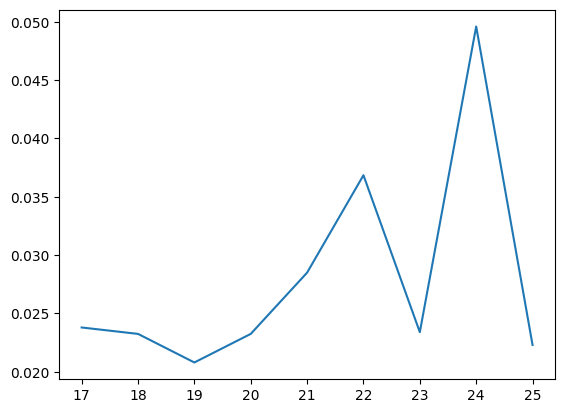

In [95]:
years = sorted(dates.keys())
point_id = 0

b2_values = [df_dict[dates[y][0]]['B2'][0] for y in years]

import matplotlib.pyplot as plt
plt.plot(years, b2_values)

In [96]:
import pandas as pd

for start, end in dates.values():
    df_dict[start]['start_date'] = start
    df_dict[start]['end_date'] = end

combined_df = pd.concat(df_dict.values(), ignore_index=True)
combined_df.to_csv("combined_df.csv", index=False)